### Checking merged probabilities across pre processing have the same count

In [1]:
import os
import pandas as pd

input_folder = '/data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/Results/Output'

csv_files = [f for f in os.listdir(input_folder) if f.endswith('.csv')]

# Load slide_name sets from each csv
slide_sets = {}
for csv_file in csv_files:
    df = pd.read_csv(os.path.join(input_folder, csv_file))
    slide_sets[csv_file] = set(df['slide_name'].tolist())
    print(f"✓ {csv_file}: {len(slide_sets[csv_file])} slides")

# Check common entries across all four
common = set.intersection(*slide_sets.values())
print(f"\n✓ Common slides across all CSVs: {len(common)}")

# Pairwise check — shows where mismatches are
print("\nPairwise overlap:")
files = list(slide_sets.keys())
for i in range(len(files)):
    for j in range(i+1, len(files)):
        overlap = slide_sets[files[i]] & slide_sets[files[j]]
        print(f"  {files[i]} ∩ {files[j]}: {len(overlap)}")

✓ TCGA_NSCLC_AB_MIL_CLAM_Probabilities.csv: 853 slides
✓ TCGA_NSCLC_AB_MIL_TRIDENT_Probabilities.csv: 853 slides
✓ TCGA_NSCLC_AB_MIL_HISTOLAB_Probabilities.csv: 853 slides
✓ TCGA_NSCLC_AB_MIL_MUFASA_Probabilities.csv: 853 slides

✓ Common slides across all CSVs: 853

Pairwise overlap:
  TCGA_NSCLC_AB_MIL_CLAM_Probabilities.csv ∩ TCGA_NSCLC_AB_MIL_TRIDENT_Probabilities.csv: 853
  TCGA_NSCLC_AB_MIL_CLAM_Probabilities.csv ∩ TCGA_NSCLC_AB_MIL_HISTOLAB_Probabilities.csv: 853
  TCGA_NSCLC_AB_MIL_CLAM_Probabilities.csv ∩ TCGA_NSCLC_AB_MIL_MUFASA_Probabilities.csv: 853
  TCGA_NSCLC_AB_MIL_TRIDENT_Probabilities.csv ∩ TCGA_NSCLC_AB_MIL_HISTOLAB_Probabilities.csv: 853
  TCGA_NSCLC_AB_MIL_TRIDENT_Probabilities.csv ∩ TCGA_NSCLC_AB_MIL_MUFASA_Probabilities.csv: 853
  TCGA_NSCLC_AB_MIL_HISTOLAB_Probabilities.csv ∩ TCGA_NSCLC_AB_MIL_MUFASA_Probabilities.csv: 853


Dataset    : TCGA_NSCLC
Models     : 11
Baselines  : ['HISTOLAB', 'TRIDENT', 'CLAM']
Significant: 12 / 33 comparisons

✓ Plot saved to: /data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/Results/TCGA_NSCLC_Bootstrap_CI.png


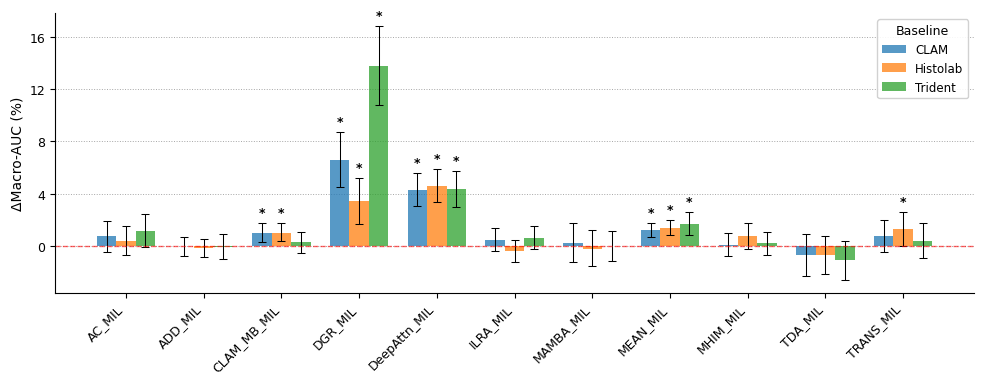

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 12, 'axes.labelsize': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5,
    'axes.facecolor': 'white', 'axes.edgecolor': 'black',
    'axes.grid': False, 'grid.color': 'lightgray', 'grid.linestyle': '--'
})

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
CSV_PATH      = '/data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/Results/AUROC/TCGA_NSCLC/TCGA_NSCLC_bootstrap_results.csv'
OUTPUT_FOLDER = '/data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/Results/'
DATASET       = 'TCGA_NSCLC'

BASELINE_COLORS = {
    'CLAM':     '#1F77B4',
    'HISTOLAB': '#FF7F0E',
    'TRIDENT':  '#2CA02C',
}

# Scale factor — multiply delta and CI by 100 to show as percentage points
# matching the reference figure's y-axis range
SCALE = 100


# ─────────────────────────────────────────────────────────────────────────────
# LOAD & PREPARE
# ─────────────────────────────────────────────────────────────────────────────
def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)

    # Scale to percentage points
    df['delta_mean'] = df['delta_mean'] * SCALE
    df['ci_low']     = df['ci_low']     * SCALE
    df['ci_high']    = df['ci_high']    * SCALE

    # Normalise secondary label capitalisation to match BASELINE_COLORS keys
    df['secondary'] = df['secondary'].str.upper()
    df['secondary'] = df['secondary'].replace({'HISTOLAB': 'HISTOLAB',
                                                'CLAM':     'CLAM',
                                                'TRIDENT':  'TRIDENT'})

    # Sort model_group alphabetically (matches reference)
    df = df.sort_values('model_group')
    return df


# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
def create_forest_plot(df, output_folder, dataset):
    unique_models   = df['model_group'].unique()          # already sorted
    baselines       = ['CLAM', 'HISTOLAB', 'TRIDENT']
    n_models        = len(unique_models)
    n_baselines     = len(baselines)

    bar_width = 0.25
    index     = np.arange(n_models)

    fig, ax = plt.subplots(figsize=(max(10, n_models * 0.9), 4))

    for i, baseline in enumerate(baselines):
        delta_means = []
        err_low     = []   # delta_mean - ci_low  (lower whisker length)
        err_high    = []   # ci_high - delta_mean  (upper whisker length)
        sig_flags   = []

        for model in unique_models:
            row = df[(df['secondary']    == baseline) &
                     (df['model_group']  == model)]
            if not row.empty:
                dm  = row['delta_mean'].values[0]
                clo = row['ci_low'].values[0]
                chi = row['ci_high'].values[0]
                sig = row['significant'].values[0]
                delta_means.append(dm)
                err_low.append(dm - clo)
                err_high.append(chi - dm)
                sig_flags.append(sig)
            else:
                delta_means.append(0)
                err_low.append(0)
                err_high.append(0)
                sig_flags.append(False)

        bars = ax.bar(
            index + i * bar_width,
            delta_means,
            bar_width,
            yerr=[err_low, err_high],
            label=baseline.capitalize() if baseline != 'CLAM' else baseline,
            color=BASELINE_COLORS[baseline],
            capsize=3,
            alpha=0.75,
            error_kw={'elinewidth': 0.75, 'capthick': 0.75, 'ecolor': 'black'}
        )

        # Mark significant bars with * above the upper CI whisker
        for j, (bar, dm, chi, sig) in enumerate(
                zip(bars, delta_means, err_high, sig_flags)):
            if sig:
                upper_tip = dm + chi
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    upper_tip + 0.3,
                    '*',
                    ha='center', va='bottom',
                    fontsize=9, color='black', fontweight='bold'
                )

    # Reference line at 0
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.6)

    # Axes formatting
    ax.set_ylabel('ΔMacro-AUC (%)', fontsize=10)
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(unique_models, rotation=45, ha='right', fontsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.grid(True, linestyle=':', which='major',
                  color='grey', alpha=0.7, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(title='Baseline', loc='upper right',
              title_fontsize=9, fontsize=8.5,
              framealpha=0.9)

    plt.tight_layout()

    os.makedirs(output_folder, exist_ok=True)
    save_path = os.path.join(output_folder, f'{dataset}_Bootstrap_CI.png')
    plt.savefig(save_path, dpi=400, bbox_inches='tight', pad_inches=0.1)
    print(f'✓ Plot saved to: {save_path}')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main():
    df = load_and_prepare(CSV_PATH)

    print(f'Dataset    : {DATASET}')
    print(f'Models     : {df["model_group"].nunique()}')
    print(f'Baselines  : {df["secondary"].unique().tolist()}')
    print(f'Significant: {df["significant"].sum()} / {len(df)} comparisons\n')

    create_forest_plot(df, OUTPUT_FOLDER, DATASET)


if __name__ == '__main__':
    main()

### Generating unique values

In [11]:
import os
import ast
import random
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
FOLDER      = "/home/rajaj/Project/7.WSI_Analysis_Experiments/1.WSI_Classification/auroc_analysis/Test1/TCGA_NSCLC"  # folder of this script
RANDOM_SEED = 42

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def decimal_digits(v):
    """Count significant decimal digits of a float."""
    s = f'{v:.18f}'.rstrip('0')
    return len(s.split('.')[-1]) if '.' in s else 0

def perturb_group(prob_list_series):
    """
    For a group of rows sharing the same [a, b], assigns unique values
    with 16-18 decimal digits.

    Case 1 — needs_perturb=True (boundary or <=5 decimal digits):
      Fill after the first 2 decimal places with unique 16-digit integers.
        [0.5, 0.5]  → [0.50<random16digits>, 1 - a_new]
        [0.0, 1.0]  → [0.00<random16digits>, 1 - a_new]
        [1.0, 0.0]  → [1 - b_new,            0.00<random16digits>]

    Case 2 — needs_perturb=False (already >5 decimal digits) AND group
      has more than one identical row:
      Keep the first 2 decimal places intact, fill the remaining 14
      digits with unique random integers so value is approximately unchanged.
        [0.819234567, 0.180765433] →
          Row 0: [0.81<unique14digits>, 1 - a_new]
          Row 1: [0.81<different14digits>, 1 - a_new]

    Single rows with >5 decimal digits are left completely unchanged.
    """
    first  = prob_list_series.iloc[0]
    a0, b0 = float(first[0]), float(first[1])
    n      = len(prob_list_series)

    used = set()   # tracks used suffixes within this group

    def unique_suffix(n_digits):
        """Returns a unique random integer string of exactly n_digits digits."""
        lo = 10 ** (n_digits - 1)
        hi = (10 ** n_digits) - 1
        while True:
            val = random.randint(lo, hi)
            if val not in used:
                used.add(val)
                return val

    needs_perturb = (
        (a0 == 0.0 and b0 == 1.0) or
        (a0 == 1.0 and b0 == 0.0) or
        decimal_digits(a0) <= 5   or
        decimal_digits(b0) <= 5
    )

    results = []
    for prob_list in prob_list_series:
        a, b = float(prob_list[0]), float(prob_list[1])

        # ── Case 1: boundary or short decimal values ──────────────────────────
        if needs_perturb:
            suffix = unique_suffix(16)

            if a == 0.0 and b == 1.0:
                # [0.0, 1.0] → [0.00<16digits>, 1 - a_new]
                a_new = float(f'0.00{suffix}')
                b_new = 1.0 - a_new

            elif a == 1.0 and b == 0.0:
                # [1.0, 0.0] → [1 - b_new, 0.00<16digits>]
                b_new = float(f'0.00{suffix}')
                a_new = 1.0 - b_new

            else:
                # e.g. [0.5, 0.5] → int_part=50 → [0.50<16digits>, 1 - a_new]
                int_part = int(round(a * 100))
                a_new    = float(f'0.{int_part:02d}{suffix}')
                b_new    = 1.0 - a_new

            results.append([a_new, b_new])

        # ── Case 2: >5 decimals but multiple identical rows in group ──────────
        elif n > 1:
            # Keep first 2 decimal places, fill remaining 14 digits uniquely.
            # e.g. a = 0.819234567 → prefix = '0.81', suffix = 14 digits
            # result: 0.81<14unique_digits>
            a_str   = f'{a:.18f}'
            dot_pos = a_str.index('.')
            prefix  = a_str[:dot_pos + 3]   # integer part + '.' + 2 decimals
            suffix  = unique_suffix(14)      # 14 unique digits to fill
            a_new   = float(f'{prefix}{suffix}')
            b_new   = 1.0 - a_new
            results.append([a_new, b_new])

        # ── Case 2 single row: completely unchanged ───────────────────────────
        else:
            results.append([a, b])

    return results

def process_folder(folder):
    csv_files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])
    if not csv_files:
        print(f'⚠️  No CSV files found in: {folder}')
        return

    for fname in csv_files:
        path = os.path.join(folder, fname)
        df   = pd.read_csv(path)

        if 'probabilities' not in df.columns:
            print(f'⚠️  No "probabilities" column in {fname} — skipping')
            continue

        # Parse string "[a, b]" → list [a, b]
        df['probabilities'] = df['probabilities'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

        # Group rows by their original (a, b) pair
        df['_prob_key'] = df['probabilities'].apply(
            lambda x: (round(float(x[0]), 18), round(float(x[1]), 18))
        )

        new_probs = df['probabilities'].copy()

        for key, group_idx in df.groupby('_prob_key').groups.items():
            group_series = df.loc[group_idx, 'probabilities']
            perturbed    = perturb_group(group_series)
            for idx, val in zip(group_idx, perturbed):
                new_probs.at[idx] = val

        df['probabilities'] = new_probs
        df = df.drop(columns=['_prob_key'])
        df.to_csv(path, index=False)

        # Verify uniqueness
        unique_count = df['probabilities'].apply(str).nunique()
        total        = len(df)
        print(f'✓ Updated : {fname}')
        print(f'  Rows    : {total}')
        print(f'  Unique  : {unique_count}')
        if unique_count < total:
            print(f'  ⚠️  {total - unique_count} duplicate pairs remain')

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    process_folder(FOLDER)

✓ Updated : TCGA_NSCLC_MAMBA_MIL_MUFASA_SET_1_calibrated_probabilities.csv
  Rows    : 853
  Unique  : 853
✓ Updated : TCGA_NSCLC_TDA_MIL_MUFASA_SET_1_calibrated_probabilities.csv
  Rows    : 853
  Unique  : 853


### Generating violin plot


────────────────────────────────────────────────────────────
Dataset: CAMELYON16
────────────────────────────────────────────────────────────


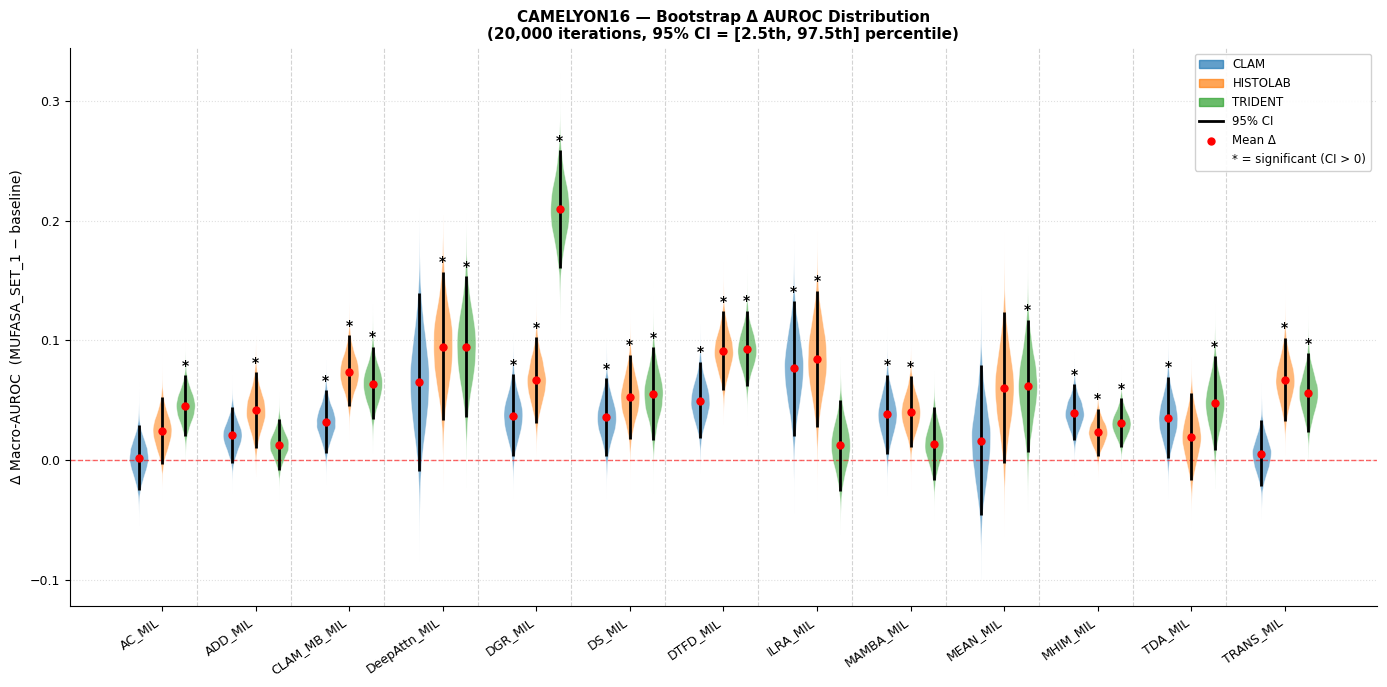

  ✓ Violin plot saved to: ViolinPlots/CAMELYON16_bootstrap_violin.png
  ✓ Summary saved to: ViolinPlots/CAMELYON16_violin_summary.csv
  Significant comparisons: 28 / 39
 model_group baseline  delta_mean  ci_low  ci_high
      AC_MIL  TRIDENT      0.0453  0.0202   0.0709
     ADD_MIL HISTOLAB      0.0414  0.0103   0.0736
 CLAM_MB_MIL     CLAM      0.0319  0.0063   0.0584
 CLAM_MB_MIL HISTOLAB      0.0738  0.0449   0.1042
 CLAM_MB_MIL  TRIDENT      0.0638  0.0343   0.0947
DeepAttn_MIL HISTOLAB      0.0948  0.0332   0.1574
DeepAttn_MIL  TRIDENT      0.0947  0.0357   0.1537
     DGR_MIL     CLAM      0.0370  0.0030   0.0715
     DGR_MIL HISTOLAB      0.0665  0.0310   0.1026
     DGR_MIL  TRIDENT      0.2095  0.1609   0.2590
      DS_MIL     CLAM      0.0356  0.0031   0.0687
      DS_MIL HISTOLAB      0.0526  0.0178   0.0881
      DS_MIL  TRIDENT      0.0554  0.0169   0.0942
    DTFD_MIL     CLAM      0.0497  0.0184   0.0823
    DTFD_MIL HISTOLAB      0.0912  0.0586   0.1244
    DTFD_MIL  T

In [16]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
INPUT_FOLDER  = '/data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/3.Results_new/AUROC'
OUTPUT_FOLDER = 'ViolinPlots'

DATASETS = ['CAMELYON16']#, 'STANFORD_793', 'TCGA_NSCLC', 'TCGA_COAD_READ']

MODEL_GROUPS = [ "AC_MIL", "ADD_MIL", "CLAM_MB_MIL", "DeepAttn_MIL", "DGR_MIL", "DS_MIL", "DTFD_MIL", "ILRA_MIL", "MAMBA_MIL", "MEAN_MIL", "MHIM_MIL", "TDA_MIL", "TRANS_MIL"]

PRIMARY_MODEL    = 'MUFASA_SET_1'
SECONDARY_MODELS = ['CLAM', 'HISTOLAB', 'TRIDENT']

BASELINE_COLORS = { 'CLAM':     '#1F77B4',
    'HISTOLAB': '#FF7F0E',
    'TRIDENT':  '#2CA02C',
}

CONFIDENCE = 0.95

plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'axes.facecolor': 'white', 'axes.edgecolor': 'black',
    'axes.grid': False,
})


# ─────────────────────────────────────────────────────────────────────────────
# LOAD & COMPUTE DELTAS
# ─────────────────────────────────────────────────────────────────────────────

def load_all_deltas(input_folder, dataset):
    """
    Reads all per-iteration CSV files for a given dataset.
    Returns a dict: {model_group: {baseline: np.array of deltas}}
    """
    all_deltas = {}

    for model_group in MODEL_GROUPS:
        fname = f'{dataset}_{model_group}_auroc_per_bootstrap_iteration.csv'
        path  = os.path.join(input_folder, dataset, fname)

        if not os.path.exists(path):
            # Try flat folder (no dataset subfolder)
            path = os.path.join(input_folder, fname)

        if not os.path.exists(path):
            print(f'  ⚠️  Missing: {fname} — skipping')
            continue

        df = pd.read_csv(path)

        if PRIMARY_MODEL not in df.columns:
            print(f'  ⚠️  {PRIMARY_MODEL} column missing in {fname} — skipping')
            continue

        model_deltas = {}
        for baseline in SECONDARY_MODELS:
            if baseline not in df.columns:
                print(f'  ⚠️  {baseline} column missing in {fname} — skipping')
                continue
            # delta per iteration
            model_deltas[baseline] = (df[PRIMARY_MODEL] - df[baseline]).values

        if model_deltas:
            all_deltas[model_group] = model_deltas

    return all_deltas


def compute_ci(deltas, confidence=0.95):
    """Compute mean, 2.5th and 97.5th percentile CI from bootstrap deltas."""
    alpha   = (1 - confidence) / 2
    mean    = float(np.mean(deltas))
    ci_low  = float(np.percentile(deltas, alpha * 100))
    ci_high = float(np.percentile(deltas, (1 - alpha) * 100))
    return mean, ci_low, ci_high


# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING — one figure per dataset
# ─────────────────────────────────────────────────────────────────────────────

def plot_violin(all_deltas, dataset, output_folder):
    """
    For each model_group × baseline combination, draws a violin of the
    20,000 bootstrap delta values with 95% CI whiskers and mean marker.
    One figure per dataset, one column per model_group.
    """
    model_groups = [mg for mg in MODEL_GROUPS if mg in all_deltas]
    n_models     = len(model_groups)
    n_baselines  = len(SECONDARY_MODELS)

    if n_models == 0:
        print(f'  ⚠️  No data to plot for {dataset}')
        return

    # Position layout: within each model_group, baselines are spaced 1 unit apart
    # model_groups are spaced n_baselines + 1 apart
    group_span = n_baselines + 1
    fig, ax    = plt.subplots(figsize=(max(14, n_models * 0.9), 7))

    xtick_positions = []
    xtick_labels    = []
    summary_rows    = []

    for g_idx, model_group in enumerate(model_groups):
        group_center = g_idx * group_span + (n_baselines - 1) / 2
        xtick_positions.append(group_center)
        xtick_labels.append(model_group)

        for b_idx, baseline in enumerate(SECONDARY_MODELS):
            if baseline not in all_deltas[model_group]:
                continue

            deltas   = all_deltas[model_group][baseline]
            pos      = g_idx * group_span + b_idx
            color    = BASELINE_COLORS[baseline]
            mean, ci_low, ci_high = compute_ci(deltas, CONFIDENCE)
            significant = ci_low > 0

            # Violin
            vp = ax.violinplot(
                deltas, positions=[pos],
                showmedians=False, showextrema=False, widths=0.8
            )
            for pc in vp['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.55)
                pc.set_edgecolor('white')
                pc.set_linewidth(0.5)

            # 95% CI whisker
            ax.vlines(pos, ci_low, ci_high,
                      color='black', linewidth=2, zorder=4)
            ax.scatter(pos, mean, color='red', zorder=5, s=25)

            # * for significant comparisons
            if significant:
                ax.text(pos, ci_high + 0.002, '*',
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', color='black')

            summary_rows.append({
                'dataset':     dataset,
                'model_group': model_group,
                'baseline':    baseline,
                'delta_mean':  round(mean, 4),
                'ci_low':      round(ci_low, 4),
                'ci_high':     round(ci_high, 4),
                'n_iters':     len(deltas),
                'significant': significant,
            })

        # Vertical separator between model groups (skip last)
        if g_idx < n_models - 1:
            ax.axvline(g_idx * group_span + n_baselines - 0.5,
                       color='lightgray', linewidth=0.8, linestyle='--', zorder=0)

    # Reference line
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)

    # Axes
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(f'Δ Macro-AUC  ({PRIMARY_MODEL} − baseline)', fontsize=10)
    ax.set_title(
        f'{dataset} — Bootstrap Δ AUC Distribution\n'
        f'(20,000 iterations, 95% CI = [2.5th, 97.5th] percentile)',
        fontsize=11, fontweight='bold'
    )
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', color='lightgray', alpha=0.7)
    ax.set_axisbelow(True)

    # Legend
    patches = [
        mpatches.Patch(color=BASELINE_COLORS[b], alpha=0.7, label=b)
        for b in SECONDARY_MODELS
    ]
    patches += [
        plt.Line2D([0], [0], color='black', linewidth=2, label='95% CI'),
        plt.scatter([], [], color='red', s=25, label='Mean Δ'),
        mpatches.Patch(color='white', label='* = significant (CI > 0)'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8.5, framealpha=0.9)

    plt.tight_layout()
    os.makedirs(output_folder, exist_ok=True)
    save_path = os.path.join(output_folder, f'{dataset}_bootstrap_violin.png')
    #plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Violin plot saved to: {save_path}')
    plt.close()

    return pd.DataFrame(summary_rows)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    all_summaries = []

    for dataset in DATASETS:
        print(f'\n{"─"*60}')
        print(f'Dataset: {dataset}')
        print(f'{"─"*60}')

        all_deltas = load_all_deltas(INPUT_FOLDER, dataset)

        if not all_deltas:
            print(f'  ⚠️  No files loaded for {dataset} — skipping')
            continue

        summary_df = plot_violin(all_deltas, dataset, OUTPUT_FOLDER)

        if summary_df is not None and not summary_df.empty:
            # Save per-dataset summary
            csv_path = os.path.join(OUTPUT_FOLDER, f'{dataset}_violin_summary.csv')
            summary_df.to_csv(csv_path, index=False)
            print(f'  ✓ Summary saved to: {csv_path}')

            sig = summary_df[summary_df['significant']]
            print(f'  Significant comparisons: {len(sig)} / {len(summary_df)}')
            if not sig.empty:
                print(sig[['model_group', 'baseline', 'delta_mean',
                            'ci_low', 'ci_high']].to_string(index=False))

            all_summaries.append(summary_df)

    # Combined summary across all datasets
    if all_summaries:
        combined = pd.concat(all_summaries, ignore_index=True)
        combined_path = os.path.join(OUTPUT_FOLDER, 'All_Datasets_violin_summary.csv')
        combined.to_csv(combined_path, index=False)
        print(f'\n✓ Combined summary saved to: {combined_path}')

    print('\n✓ Done.')


if __name__ == '__main__':
    main()

### Final


────────────────────────────────────────────────────────────
Dataset: TCGA_NSCLC
────────────────────────────────────────────────────────────


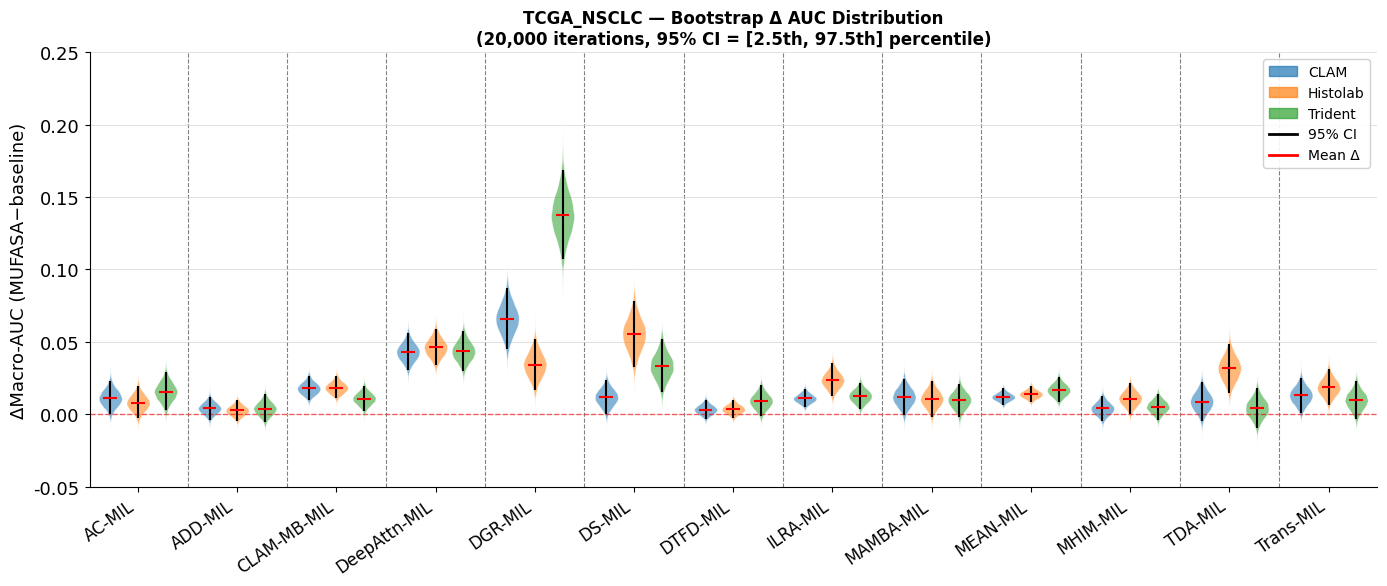

  ✓ Violin plot saved to: ViolinPlots/TCGA_NSCLC_bootstrap_violin.png
  ✓ Summary saved to: ViolinPlots/TCGA_NSCLC_violin_summary.csv
  Significant comparisons: 24 / 39
 model_group baseline  delta_mean  ci_low  ci_high
      AC_MIL     CLAM      0.0113  0.0000   0.0233
      AC_MIL  TRIDENT      0.0157  0.0027   0.0289
 CLAM_MB_MIL     CLAM      0.0180  0.0100   0.0267
 CLAM_MB_MIL HISTOLAB      0.0184  0.0110   0.0265
 CLAM_MB_MIL  TRIDENT      0.0109  0.0023   0.0196
DeepAttn_MIL     CLAM      0.0431  0.0308   0.0558
DeepAttn_MIL HISTOLAB      0.0462  0.0337   0.0591
DeepAttn_MIL  TRIDENT      0.0436  0.0301   0.0575
     DGR_MIL     CLAM      0.0661  0.0452   0.0874
     DGR_MIL HISTOLAB      0.0343  0.0170   0.0519
     DGR_MIL  TRIDENT      0.1378  0.1076   0.1685
      DS_MIL     CLAM      0.0118  0.0001   0.0236
      DS_MIL HISTOLAB      0.0553  0.0328   0.0780
      DS_MIL  TRIDENT      0.0334  0.0157   0.0519
    ILRA_MIL     CLAM      0.0111  0.0051   0.0176
    ILRA_MIL HI

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
INPUT_FOLDER  = '/data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/3.Results_new/AUROC'
OUTPUT_FOLDER = 'ViolinPlots'

DATASETS = ['TCGA_NSCLC']
#'CAMELYON16' , 'STANFORD_793', 'TCGA_NSCLC', 'TCGA_COAD_READ

MODEL_GROUPS = ["AC_MIL", "ADD_MIL", "CLAM_MB_MIL", "DeepAttn_MIL", "DGR_MIL", "DS_MIL", "DTFD_MIL", "ILRA_MIL", "MAMBA_MIL", "MEAN_MIL", "MHIM_MIL", "TDA_MIL", "TRANS_MIL"]

PRIMARY_MODEL    = 'MUFASA_SET_1'
SECONDARY_MODELS = ['CLAM', 'HISTOLAB', 'TRIDENT']

BASELINE_COLORS = { 'CLAM': '#1F77B4', 'HISTOLAB': '#FF7F0E', 'TRIDENT': '#2CA02C',}

# Display names used in legend
LEGEND_LABELS = { 'CLAM': 'CLAM', 'HISTOLAB': 'Histolab', 'TRIDENT': 'Trident',}

XTICK_LABELS = ["AC-MIL", "ADD-MIL", "CLAM-MB-MIL", "DeepAttn-MIL", "DGR-MIL", "DS-MIL", "DTFD-MIL", "ILRA-MIL", "MAMBA-MIL", 
                "MEAN-MIL","MHIM-MIL", "TDA-MIL", "Trans-MIL"]

#XTICK_LABELS = None  for original x tick values

CONFIDENCE = 0.95

plt.rcParams.update({ 'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 13, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
                    'axes.facecolor': 'white', 'axes.edgecolor': 'black', 'axes.grid': False,})

# ─────────────────────────────────────────────────────────────────────────────
# LOAD & COMPUTE DELTAS
# ─────────────────────────────────────────────────────────────────────────────
def load_all_deltas(input_folder, dataset):
    """
    Reads all per-iteration CSV files for a given dataset.
    Returns a dict: {model_group: {baseline: np.array of deltas}}
    """
    all_deltas = {}

    for model_group in MODEL_GROUPS:
        fname = f'{dataset}_{model_group}_auroc_per_bootstrap_iteration.csv'
        path  = os.path.join(input_folder, dataset, fname)

        if not os.path.exists(path):
            # Try flat folder (no dataset subfolder)
            path = os.path.join(input_folder, fname)
        if not os.path.exists(path):
            print(f'  ⚠️  Missing: {fname} — skipping')
            continue

        df = pd.read_csv(path)
        if PRIMARY_MODEL not in df.columns:
            print(f'  ⚠️  {PRIMARY_MODEL} column missing in {fname} — skipping')
            continue

        model_deltas = {}
        for baseline in SECONDARY_MODELS:
            if baseline not in df.columns:
                print(f'  ⚠️  {baseline} column missing in {fname} — skipping')
                continue
            model_deltas[baseline] = (df[PRIMARY_MODEL] - df[baseline]).values
        if model_deltas:
            all_deltas[model_group] = model_deltas

    return all_deltas

def compute_ci(deltas, confidence=0.95):
    """Compute mean, 2.5th and 97.5th percentile CI from bootstrap deltas."""
    alpha   = (1 - confidence) / 2
    mean    = float(np.mean(deltas))
    ci_low  = float(np.percentile(deltas, alpha * 100))
    ci_high = float(np.percentile(deltas, (1 - alpha) * 100))
    return mean, ci_low, ci_high

# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING — one figure per dataset
# ─────────────────────────────────────────────────────────────────────────────
def plot_violin(all_deltas, dataset, output_folder):
    model_groups = [mg for mg in MODEL_GROUPS if mg in all_deltas]
    n_models     = len(model_groups)
    n_baselines  = len(SECONDARY_MODELS)

    if n_models == 0:
        print(f'  ⚠️  No data to plot for {dataset}')
        return
    intra_spacing = 0.6    # ← gap between violins within one model group
    inter_gap     = 0.35    # ← gap between model groups
    group_span    = n_baselines * intra_spacing + inter_gap

    fig, ax = plt.subplots(figsize=(max(14, n_models * 0.7), 6))
    xtick_positions = []
    xtick_labels    = []
    summary_rows    = []

    for g_idx, model_group in enumerate(model_groups):
        group_center = g_idx * group_span + (n_baselines - 1) * intra_spacing / 2
        xtick_positions.append(group_center)
        xtick_labels.append(model_group)

        for b_idx, baseline in enumerate(SECONDARY_MODELS):
            if baseline not in all_deltas[model_group]:
                continue

            deltas              = all_deltas[model_group][baseline]
            pos                 = g_idx * group_span + b_idx * intra_spacing
            color               = BASELINE_COLORS[baseline]
            mean, ci_low, ci_high = compute_ci(deltas, CONFIDENCE)
            significant         = ci_low > 0

            vp = ax.violinplot(deltas, positions=[pos], showmedians=False, showextrema=False, widths=0.5)
            for pc in vp['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.55)
                pc.set_edgecolor('white')
                pc.set_linewidth(0.5)

            ax.vlines(pos, ci_low, ci_high, color='black', linewidth=1.5, zorder=4)
            ax.hlines(mean, pos - 0.15, pos + 0.15, color='red', linewidth=1.5, zorder=5)

            summary_rows.append({
                'dataset':     dataset,
                'model_group': model_group,
                'baseline':    baseline,
                'delta_mean':  round(mean, 4),
                'ci_low':      round(ci_low, 4),
                'ci_high':     round(ci_high, 4),
                'n_iters':     len(deltas),
                'significant': significant,
            })

        if g_idx < n_models - 1: 
            last_pos_this  = g_idx * group_span + (n_baselines - 1) * intra_spacing
            first_pos_next = (g_idx + 1) * group_span
            ax.axvline((last_pos_this + first_pos_next) / 2, color='gray', linewidth=0.8, linestyle='--', zorder=0)
    half_violin = 0.45
    ax.set_xlim(-half_violin,(n_models - 1) * group_span + (n_baselines - 1) * intra_spacing + half_violin)
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(xtick_positions)
    display_labels = XTICK_LABELS if XTICK_LABELS is not None else xtick_labels
    ax.set_xticklabels(display_labels, rotation=35, ha='right', fontsize=12)
    ax.set_ylabel('ΔMacro-AUC (MUFASA−baseline)', fontsize=13)
    ax.set_title( f'{dataset} — Bootstrap Δ AUC Distribution\n' f'(20,000 iterations, 95% CI = [2.5th, 97.5th] percentile)', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_axisbelow(True)

    y_min, y_max = ax.get_ylim()
    step  = 0.05
    ticks = np.arange(np.floor(y_min / step) * step, np.ceil(y_max  / step) * step + step, step)
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))   # ← two decimals
    ax.yaxis.grid(True, linestyle='-', color='lightgray', alpha=0.7, linewidth=0.7)

    patches = [
        mpatches.Patch(color=BASELINE_COLORS[b], alpha=0.7, label=LEGEND_LABELS[b])
        for b in SECONDARY_MODELS
    ]
    patches += [
        plt.Line2D([0], [0], color='black', linewidth=2, label='95% CI'),
        plt.Line2D([0], [0], color='red',   linewidth=2, label='Mean Δ'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=10, framealpha=0.9)

    plt.tight_layout()
    os.makedirs(output_folder, exist_ok=True)
    save_path = os.path.join(output_folder, f'{dataset}_bootstrap_violin.png')
    plt.savefig(save_path, dpi=450, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Violin plot saved to: {save_path}')
    plt.close()
    return pd.DataFrame(summary_rows)

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    all_summaries = []

    for dataset in DATASETS:
        print(f'\n{"─"*60}')
        print(f'Dataset: {dataset}')
        print(f'{"─"*60}')

        all_deltas = load_all_deltas(INPUT_FOLDER, dataset)

        if not all_deltas:
            print(f'  ⚠️  No files loaded for {dataset} — skipping')
            continue

        summary_df = plot_violin(all_deltas, dataset, OUTPUT_FOLDER)
        if summary_df is not None and not summary_df.empty:
            csv_path = os.path.join(OUTPUT_FOLDER, f'{dataset}_violin_summary.csv')
            summary_df.to_csv(csv_path, index=False)
            print(f'  ✓ Summary saved to: {csv_path}')
            sig = summary_df[summary_df['significant']]
            print(f'  Significant comparisons: {len(sig)} / {len(summary_df)}')
            if not sig.empty:
                print(sig[['model_group', 'baseline', 'delta_mean', 'ci_low', 'ci_high']].to_string(index=False))
            all_summaries.append(summary_df)

    if all_summaries:
        combined      = pd.concat(all_summaries, ignore_index=True)
        combined_path = os.path.join(OUTPUT_FOLDER, 'All_Datasets_violin_summary.csv')
        combined.to_csv(combined_path, index=False)
        print(f'\n✓ Combined summary saved to: {combined_path}')
    print('\n✓ Done.')

if __name__ == '__main__':
    main()

### Clipping the range

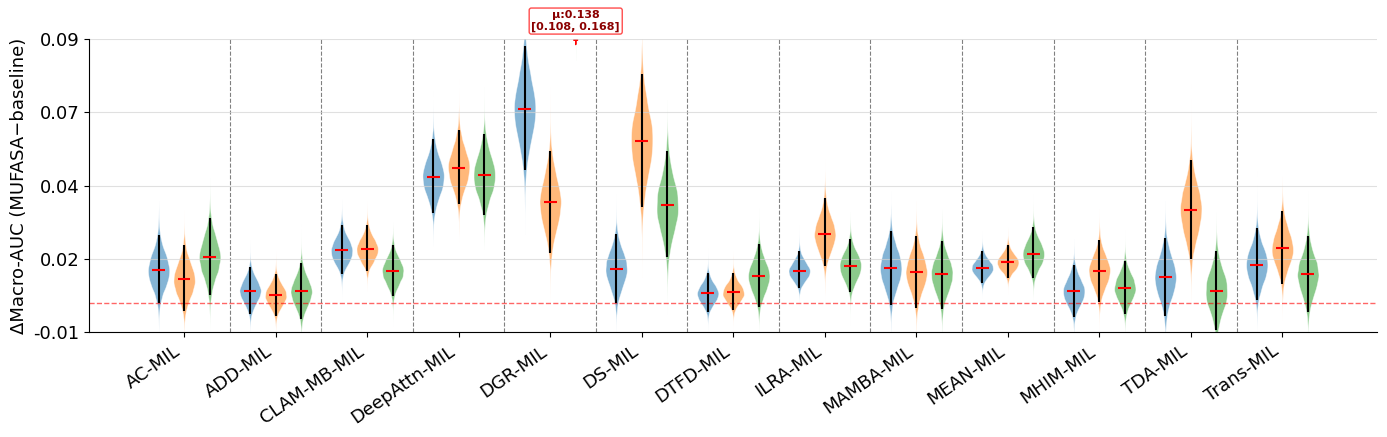

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
INPUT_FOLDER  = '/data_64T_3/Raja/MUFASA/1.WSI_Classification/AUROC_Analysis/3.Results_new/AUROC'
OUTPUT_FOLDER = 'ViolinPlots'

DATASETS = ['TCGA_NSCLC']
#'CAMELYON16' , 'STANFORD_793', 'TCGA_NSCLC', 'TCGA_COAD_READ
MODEL_GROUPS = ["AC_MIL", "ADD_MIL", "CLAM_MB_MIL", "DeepAttn_MIL", "DGR_MIL", "DS_MIL", "DTFD_MIL", "ILRA_MIL", "MAMBA_MIL", "MEAN_MIL", "MHIM_MIL", "TDA_MIL", "TRANS_MIL"]

PRIMARY_MODEL    = 'MUFASA_SET_1'
SECONDARY_MODELS = ['CLAM', 'HISTOLAB', 'TRIDENT']

BASELINE_COLORS = { 'CLAM': '#1F77B4', 'HISTOLAB': '#FF7F0E', 'TRIDENT': '#2CA02C',}
LEGEND_LABELS = { 'CLAM': 'CLAM', 'HISTOLAB': 'Histolab', 'TRIDENT': 'Trident',}

XTICK_LABELS = ["AC-MIL", "ADD-MIL", "CLAM-MB-MIL", "DeepAttn-MIL", "DGR-MIL", "DS-MIL", "DTFD-MIL", "ILRA-MIL", "MAMBA-MIL", 
                "MEAN-MIL","MHIM-MIL", "TDA-MIL", "Trans-MIL"]

CONFIDENCE = 0.95
Y_LIM = (-0.01, 0.09) # Hard limits for the Y-axis
step = 0.025

plt.rcParams.update({ 'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 13, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
                    'axes.facecolor': 'white', 'axes.edgecolor': 'black', 'axes.grid': False,})

# ─────────────────────────────────────────────────────────────────────────────
# LOAD & COMPUTE DELTAS
# ─────────────────────────────────────────────────────────────────────────────
def load_all_deltas(input_folder, dataset):
    all_deltas = {}
    for model_group in MODEL_GROUPS:
        fname = f'{dataset}_{model_group}_auroc_per_bootstrap_iteration.csv'
        path  = os.path.join(input_folder, dataset, fname)

        if not os.path.exists(path):
            path = os.path.join(input_folder, fname)
        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)
        if PRIMARY_MODEL not in df.columns:
            continue

        model_deltas = {}
        for baseline in SECONDARY_MODELS:
            if baseline in df.columns:
                model_deltas[baseline] = (df[PRIMARY_MODEL] - df[baseline]).values
        if model_deltas:
            all_deltas[model_group] = model_deltas
    return all_deltas
    
def compute_ci(deltas, confidence=0.95):
    alpha   = (1 - confidence) / 2
    mean    = float(np.mean(deltas))
    ci_low  = float(np.percentile(deltas, alpha * 100))
    ci_high = float(np.percentile(deltas, (1 - alpha) * 100))
    return mean, ci_low, ci_high

# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────────────────────────────────────
def plot_violin(all_deltas, dataset, output_folder):
    model_groups = [mg for mg in MODEL_GROUPS if mg in all_deltas]
    n_models     = len(model_groups)
    n_baselines  = len(SECONDARY_MODELS)

    if n_models == 0: return None
        
    intra_spacing = 0.6
    inter_gap     = 0.35
    group_span    = n_baselines * intra_spacing + inter_gap

    fig, ax = plt.subplots(figsize=(max(14, n_models * 0.7), 4.5))
    xtick_positions = []
    summary_rows = []

    for g_idx, model_group in enumerate(model_groups):
        group_center = g_idx * group_span + (n_baselines - 1) * intra_spacing / 2
        xtick_positions.append(group_center)

        for b_idx, baseline in enumerate(SECONDARY_MODELS):
            if baseline not in all_deltas[model_group]: continue

            deltas = all_deltas[model_group][baseline]
            pos = g_idx * group_span + b_idx * intra_spacing
            color = BASELINE_COLORS[baseline]
            mean, ci_low, ci_high = compute_ci(deltas, CONFIDENCE)
            
            # Create Violin
            vp = ax.violinplot(deltas, positions=[pos], showmedians=False, showextrema=False, widths=0.5)
            for pc in vp['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.55)
                pc.set_edgecolor('white')
                pc.set_linewidth(0.5)

            # Draw CI and Mean (Clipped visually by Y_LIM later)
            ax.vlines(pos, max(ci_low, Y_LIM[0]), min(ci_high, Y_LIM[1]), color='black', linewidth=1.5, zorder=4)
            
            # Only draw mean line if it is within view
            if Y_LIM[0] <= mean <= Y_LIM[1]:
                ax.hlines(mean, pos - 0.15, pos + 0.15, color='red', linewidth=1.5, zorder=5)

            # ─────────────────────────────────────────────────────────────────
            # OUTLIER INDICATORS (If data exceeds Y_LIM[1])
            # ─────────────────────────────────────────────────────────────────
            if ci_high > Y_LIM[1]:
                # ax.annotate(f'↑{ci_high:.3f}', xy=(pos, Y_LIM[1]), xytext=(0, 3),
                #             textcoords='offset points', ha='center', va='bottom',
                #             fontsize=9, color='red', fontweight='bold')
                # Construct a string: Mean (CI_Low, CI_High)
                # We use \n to keep the text block narrow and readable
                outlier_text = f"μ:{mean:.3f}\n[{ci_low:.3f}, {ci_high:.3f}]"
                
                ax.annotate(outlier_text, 
                            xy=(pos, Y_LIM[1]), 
                            xytext=(0, 5), # 5 points above the ceiling
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=8, 
                            color='darkred', 
                            fontweight='bold',
                            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='red', alpha=0.7))
                
                # Optional: Draw a small arrow pointing up to reinforce the visual
                ax.arrow(pos, Y_LIM[1] - 0.002, 0, 0.0015, 
                         head_width=0.1, head_length=0.001, fc='red', ec='red')
            
            if ci_low < Y_LIM[0]:
                # ax.annotate(f'↓{ci_low:.3f}', xy=(pos, Y_LIM[0]), xytext=(0, -12),
                #             textcoords='offset points', ha='center', va='bottom',
                #             fontsize=9, color='blue', fontweight='bold')
                outlier_text_low = f"μ:{mean:.3f}\n[{ci_low:.3f}, {ci_high:.3f}]"
                ax.annotate(outlier_text_low, 
                            xy=(pos, Y_LIM[0]), 
                            xytext=(0, -25), # Below the floor
                            textcoords='offset points',
                            ha='center', va='top',
                            fontsize=8, 
                            color='blue', 
                            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='blue', alpha=0.7))
            summary_rows.append({
                'dataset': dataset, 'model_group': model_group, 'baseline': baseline,
                'delta_mean': round(mean, 4), 'ci_low': round(ci_low, 4), 'ci_high': round(ci_high, 4),
                'significant': ci_low > 0
            })

        if g_idx < n_models - 1: 
            sep_pos = (g_idx * group_span + (n_baselines - 1) * intra_spacing + (g_idx + 1) * group_span) / 2
            ax.axvline(sep_pos, color='gray', linewidth=0.8, linestyle='--', zorder=0)

    # Styling
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(XTICK_LABELS if XTICK_LABELS else model_groups, rotation=35, ha='right')
    ax.set_ylabel('ΔMacro-AUC (MUFASA−baseline)')
    # ax.set_title(f'{dataset} — Bootstrap Δ AUC Distribution\n(Values outside [{Y_LIM[0]}, {Y_LIM[1]}] annotated)', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

    # Strict Limits and Ticks
    ax.set_ylim(Y_LIM)
    tick_values = np.arange(Y_LIM[0], Y_LIM[1] + 0.001, step)
    ax.set_yticks(tick_values)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.yaxis.grid(True, linestyle='-', color='lightgray', alpha=0.7)

    # Legend
    patches = [mpatches.Patch(color=BASELINE_COLORS[b], alpha=0.7, label=LEGEND_LABELS[b]) for b in SECONDARY_MODELS]
    patches += [plt.Line2D([0], [0], color='black', linewidth=2, label='95% CI'),
                plt.Line2D([0], [0], color='red', linewidth=2, label='Mean Δ')]
    
    # ax.legend(handles=patches, loc='upper right', framealpha=0.9, bbox_to_anchor=(1, 1))

    plt.tight_layout()
    save_path = os.path.join(output_folder, f'{dataset}_bootstrap_violin.png')
    plt.savefig(save_path, dpi=450, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(summary_rows)

def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    for dataset in DATASETS:
        all_deltas = load_all_deltas(INPUT_FOLDER, dataset)
        if all_deltas:
            plot_violin(all_deltas, dataset, OUTPUT_FOLDER)

if __name__ == '__main__':
    main()